In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
n = 90

df = pd.DataFrame({
    "participant": range(1, n + 1),
    "network_change": np.random.normal(0.0, 0.95, n),
    "cognitive_score": np.random.normal(74, 7, n),
    "reaction_time": np.random.normal(780, 95, n),
    "flexibility_score": np.random.normal(0.62, 0.11, n)
})

df.head()

,participant,network_change,cognitive_score,reaction_time,flexibility_score
0,1,0.471878,74.679543,839.438398,0.778540
1,2,-0.131351,80.780515,698.570032,0.462055
2,3,0.615304,69.085628,678.265213,0.747948
3,4,1.446878,71.706365,825.834879,0.621126
4,5,-0.222446,71.255243,758.771035,0.512034


In [4]:
features = df[
    ["network_change", "cognitive_score", "reaction_time", "flexibility_score"]
]

X = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X).astype(str)

df["cluster"].value_counts()

,count
cluster,
2,33
0,29
1,28


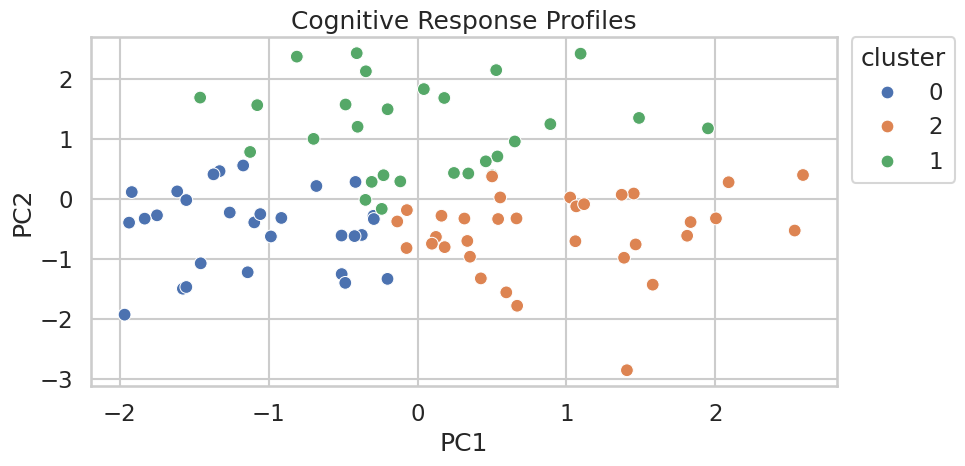

In [5]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

plot_df = df.copy()
plot_df["pc1"] = coords[:,0]
plot_df["pc2"] = coords[:,1]

plt.figure(figsize=(10,5))

ax = sns.scatterplot(
    data=plot_df,
    x="pc1",
    y="pc2",
    hue="cluster",
    s=85
)

ax.legend(
    title="cluster",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cognitive Response Profiles")
plt.tight_layout()
plt.savefig("figures/04_cognitive_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
profiles = (
    df.groupby("cluster")[
        ["network_change", "cognitive_score", "reaction_time", "flexibility_score"]
    ]
    .mean()
    .round(2)
)

profiles.to_csv("outputs/04_cluster_profiles.csv")
df.to_csv("outputs/04_participant_profiles.csv", index=False)

profiles

,network_change,cognitive_score,reaction_time,flexibility_score
cluster,,,,
0,-0.28,70.50,743.03,0.72
1,0.69,72.67,846.21,0.59
2,-0.60,79.24,753.74,0.58
